![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 E13 - Custom tools robustas
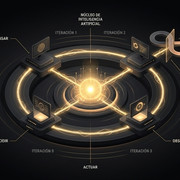

*Figura E13. Custom tools robustas con errores estructurados.*

## Escenario

Cerramos el arco del reporte semanal de ventas llevando las herramientas a una version mas cercana a produccion.

Una custom tool se crea cuando necesitamos:

- datos propietarios;
- reglas de negocio;
- servicios autenticados;
- validaciones del dominio;
- salidas predecibles para un agente.


## Romper el agente a proposito


In [ ]:
def buscar_datos_ventas_roto() -> list[dict]:
    """Herramienta rota: no devuelve datos."""
    return []


def calcular_total_roto(filas):
    """Herramienta rota: asume que el input siempre es valido."""
    return sum(fila["unidades"] * fila["precio_unitario"] for fila in filas)


filas_vacias = buscar_datos_ventas_roto()
print(f"buscar_datos_ventas_roto() -> {filas_vacias}")
print(f"calcular_total_roto(filas_vacias) -> {calcular_total_roto(filas_vacias)}")

try:
    print(calcular_total_roto(None))
except Exception as error:
    print(f"calcular_total_roto(None) fallo -> {type(error).__name__}: {error}")


## Solucion - version robusta


In [ ]:
def buscar_datos_ventas() -> dict:
    """Herramienta robusta: busca ventas y devuelve salida estructurada."""
    filas = []
    if not filas:
        return {"exito": False, "datos": [], "codigo_error": "SIN_DATOS_VENTAS"}
    return {"exito": True, "datos": filas, "codigo_error": None}


def calcular_total(filas) -> dict:
    """Herramienta robusta: calcula total con validacion."""
    if not isinstance(filas, list) or not filas:
        return {"exito": False, "datos": 0, "codigo_error": "FILAS_INVALIDAS"}

    try:
        total = sum(float(fila["unidades"]) * float(fila["precio_unitario"]) for fila in filas)
    except (KeyError, TypeError, ValueError) as error:
        return {"exito": False, "datos": 0, "codigo_error": f"FILA_MAL_FORMADA: {error}"}

    return {"exito": True, "datos": total, "codigo_error": None}


print(f"buscar_datos_ventas() -> {buscar_datos_ventas()}")
print(f"calcular_total(None) -> {calcular_total(None)}")
print(f"calcular_total([]) -> {calcular_total([])}")


## Ejercicio final - ejemplo de herramienta


In [ ]:
# Ejemplo final: herramienta de prioridad de seguimiento CRM.
diseno_herramienta = {
    "nombre": "priorizar_seguimientos_crm",
    "descripcion": "Ordena clientes de CRM por urgencia usando valor de oportunidad, fecha de ultimo contacto e incidentes de soporte abiertos.",
    "entradas_tipadas": {
        "clientes": "list[dict]",
        "max_resultados": "int",
    },
    "salidas_predecibles": {
        "exito": "bool",
        "datos": "list[dict]",
        "codigo_error": "str | None",
    },
    "errores_posibles": ["CLIENTES_INVALIDOS", "CLIENTES_VACIOS", "MAX_RESULTADOS_INVALIDO"],
    "cuando_usarla": "Usar cuando el usuario pregunta que clientes deberia contactar primero.",
    "cuando_no_usarla": "No usar para crear emails ni actualizar registros del CRM.",
}

print(diseno_herramienta)


## Reflexion final

1. ¿Qué cambia entre una herramienta rota y una robusta?
2. ¿Por qué `exito/codigo_error` ayuda al agente?
3. ¿Cuándo conviene crear una custom tool en vez de pedirle todo al LLM?
4. ¿Qué parte del reporte semanal de ventas llevarias a una herramienta real?
5. ¿Qué datos no deberia inventar nunca el agente?
